In [1]:
"""
*Uncomment if running on colab* 
Set Runtime -> Change runtime type -> Under Hardware Accelerator select GPU in Google Colab 
"""
# !git clone https://github.com/DmitryUlyanov/deep-image-prior
# !mv deep-image-prior/* ./

'\n*Uncomment if running on colab* \nSet Runtime -> Change runtime type -> Under Hardware Accelerator select GPU in Google Colab \n'

# Import libs

In [1]:
from __future__ import print_function
import matplotlib.pyplot as plt
%matplotlib inline

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '3'

import numpy as np
from models import *

import torch
import torch.optim

from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim
from utils.denoising_utils import *

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark =True
dtype = torch.cuda.FloatTensor

imsize =-1
PLOT = True
sigma = 25
sigma_ = sigma/255.
torch.manual_seed(2025) 
np.random.seed(2025)

In [2]:
# deJPEG 
# fname = 'data/denoising/snail.jpg'

## denoising
fname = 'data/denoising/F16_GT.png'

# Load image

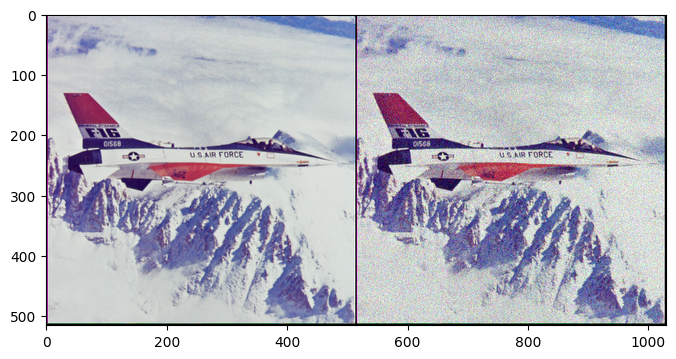

In [3]:
img_pil = crop_image(get_image(fname, imsize)[0], d=32)
img_np = pil_to_np(img_pil)

img_noisy_pil, img_noisy_np = get_noisy_image(img_np, sigma_)
img_noisy_torch = np_to_torch(img_noisy_np).type(dtype)
if PLOT:
    plot_image_grid([img_np, img_noisy_np], 4, 6);

In [4]:
def residual_spectral_moment2_image(x, alpha=1.0, eps=1e-12):
    rr = x 
    C, H, W = rr.shape
    
    Rf = torch.fft.fft2(rr, norm='ortho')
    Rf = torch.fft.fftshift(Rf, dim=(-2, -1))

    fy = torch.fft.fftfreq(H, d=1.0, device=rr.device)
    fx = torch.fft.fftfreq(W, d=1.0, device=rr.device)
    
    fy = torch.fft.fftshift(fy)
    fx = torch.fft.fftshift(fx)
    
    grid_y, grid_x = torch.meshgrid(fy, fx, indexing='ij')
    freq_radius = torch.sqrt(grid_x**2 + grid_y**2)

    power = torch.abs(Rf)**2

    weighted_power = (freq_radius**alpha) * power
    numerator = torch.sum(weighted_power)

    denominator = torch.sum(rr**2)

    return numerator / (denominator + eps)
def residual_spectral_moment2(x, y, alpha=1.0, eps=1e-12):
    rr = x - y  
    B, C, H, W = rr.shape

    Rf = torch.fft.fft2(rr, norm='ortho')
    Rf = torch.fft.fftshift(Rf, dim=(-2, -1))

    fy = torch.fft.fftfreq(H, d=1.0, device=rr.device)
    fx = torch.fft.fftfreq(W, d=1.0, device=rr.device)

    fy = torch.fft.fftshift(fy)
    fx = torch.fft.fftshift(fx)
    
    grid_y, grid_x = torch.meshgrid(fy, fx, indexing='ij')
    freq_radius = torch.sqrt(grid_x**2 + grid_y**2)

    power = torch.abs(Rf)**2

    weighted_power = (freq_radius**alpha) * power
    numerator = torch.sum(weighted_power)

    denominator = torch.sum(rr**2)

    return numerator / (denominator + eps)

# Setup

In [5]:
INPUT = 'noise' # 'meshgrid'
pad = 'reflection'
OPT_OVER = 'net' # 'net,input'

reg_noise_std = 0 #1./30. # set to 1./20. for sigma=50
LR = 1 #0.01

OPTIMIZER= 'LBFGS' #'adam' #'LBFGS'
show_every = 200
exp_weight=0.99

num_iter = 1000
input_depth = 32 
figsize = 4 
net_input0 = get_noise(input_depth, INPUT, (img_pil.size[1], img_pil.size[0])).type(dtype).detach()


# skip net

In [ ]:
net_type = 'skip'
act = 'LeakyReLU'

net = get_net(input_depth, net_type, pad,
                skip_n33d=128, 
                skip_n33u=128, 
                skip_n11=4, 
                num_scales=5,
                upsample_mode='bilinear',
                act_fun=act).type(dtype)
    
net_input = net_input0
# Compute number of parameters
s  = sum([np.prod(list(p.size())) for p in net.parameters()]); 
print ('Number of params: %d' % s)

# Loss
mse = torch.nn.MSELoss().type(dtype)

Number of params: 436523


Starting optimization with LBFGS


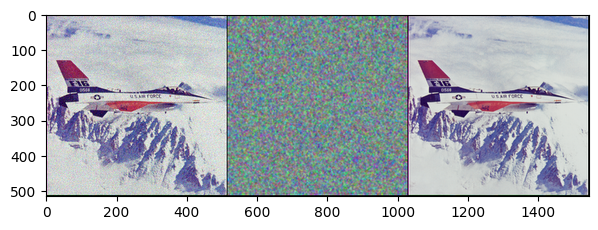

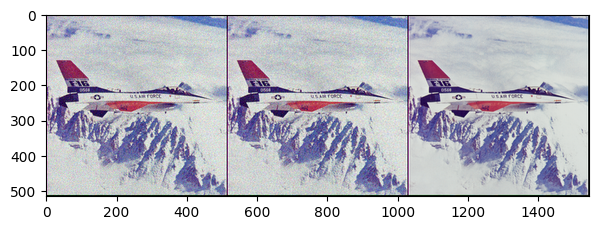

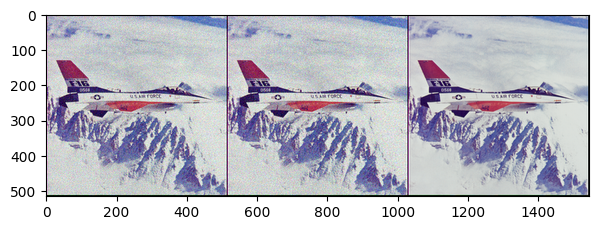

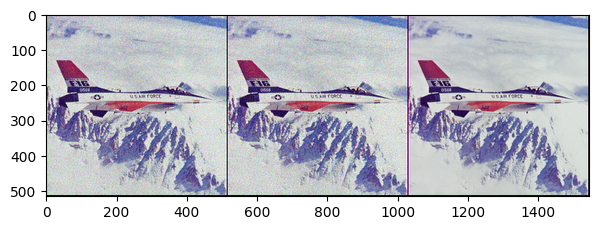

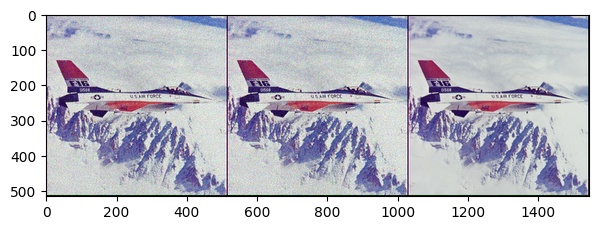

In [7]:
net_input_saved = net_input.detach().clone()
noise = net_input.detach().clone()
out_avg = None
last_net = None
psrn_noisy_last = 0

loss_values = []
psnr_values = []
psnr_sm_values = []
psnr_noisy_values = []
finalresult = []

i = 0
def closure():
    
    global i, out_avg, psrn_noisy_last, last_net, net_input
    
    if reg_noise_std > 0:
        net_input = net_input_saved + (noise.normal_() * reg_noise_std)
    
    out = net(net_input)
    
    # Smoothing
    if out_avg is None:
        out_avg = out.detach()
    else:
        out_avg = out_avg * exp_weight + out.detach() * (1 - exp_weight)
            
    total_loss = mse(out, img_noisy_torch)
    total_loss.backward()
        
    psrn_gt    = compare_psnr(img_np, out.detach().cpu().numpy()[0]) 
    psrn_gt_sm = compare_psnr(img_np, out_avg.detach().cpu().numpy()[0]) 

    loss_values.append(total_loss.item())
    psnr_values.append(psrn_gt)
    psnr_sm_values.append(psrn_gt_sm)
    finalresult.append(out.detach().cpu())

    print ('Iteration %05d    Loss %f   PSRN_gt: %f PSNR_gt_sm: %f' % (i, total_loss.item(), psrn_gt, psrn_gt_sm), '\r', end='')
    if  PLOT and i % show_every == 0:
        out_np = torch_to_np(out)
        plot_image_grid([img_noisy_np, np.clip(out_np, 0, 1), 
                         img_np], factor=figsize)
        
            
    i += 1

    return total_loss

p = get_params(OPT_OVER, net, net_input)
optimize(OPTIMIZER, p, closure, LR, num_iter)

results = {}
results[f'{OPTIMIZER}_{net_type}_{act}'] = {
    'loss': loss_values,
    'psnr': psnr_values,
    'psnr_sm': psnr_sm_values,
    'psnr_noisy': psnr_noisy_values,
    'finalresult': finalresult,
}

In [8]:
xx = torch.from_numpy(img_np.astype(np.float32))
print(f'GT bias: {residual_spectral_moment2_image(xx, alpha=1).item()}')
yy = torch.from_numpy(img_noisy_np.astype(np.float32))
print(f'Observation bias: {residual_spectral_moment2_image(yy, alpha=1).item()}')

GT bias: 0.0020601621363312006
Observation bias: 0.008449049666523933


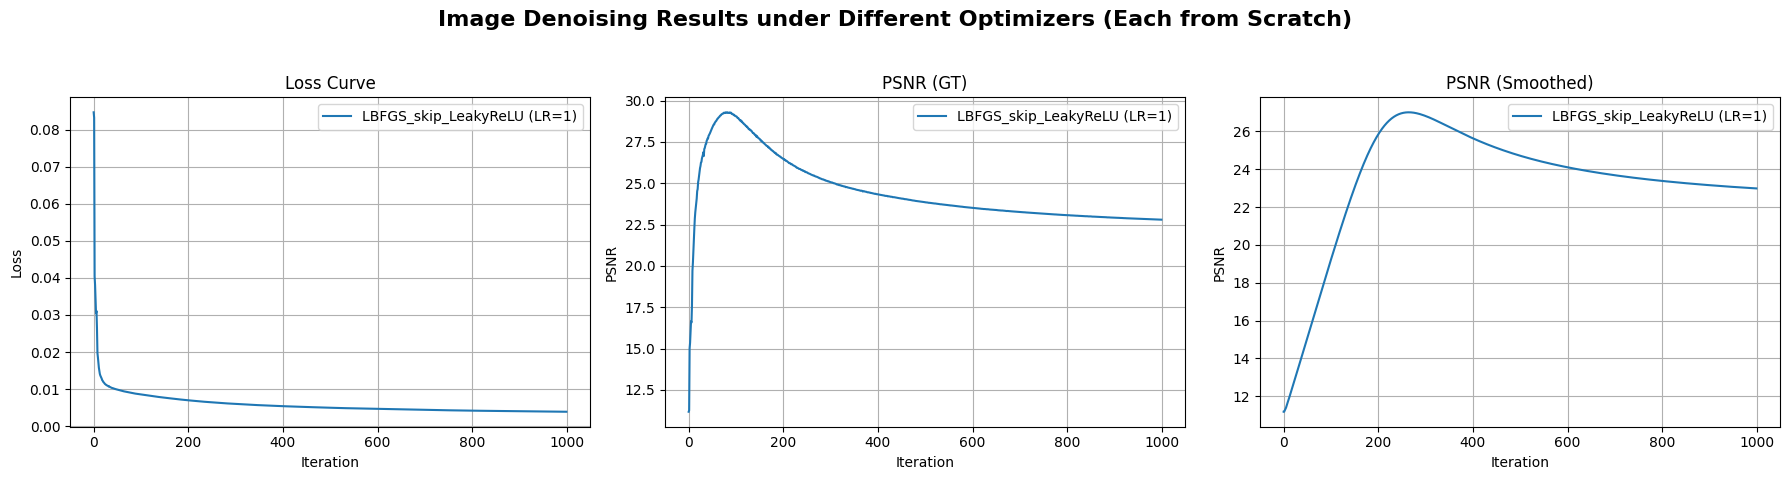

In [9]:
# ========== plot ========== # 
plt.figure(figsize=(18, 5))

# ---- (1) Loss ----
plt.subplot(1, 3, 1)
for opt_name, data in results.items():
    plt.plot(data['loss'], label=f'{opt_name} (LR={LR})')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)

# ---- (2) PSNR (GT) ----
plt.subplot(1, 3, 2)
for opt_name, data in results.items():
    plt.plot(data['psnr'], label=f'{opt_name} (LR={LR})')
plt.xlabel('Iteration')
plt.ylabel('PSNR')
plt.title('PSNR (GT)')
plt.legend()
plt.grid(True)

# ---- (3) PSNR (Smoothed) ----
plt.subplot(1, 3, 3)
for opt_name, data in results.items():
    plt.plot(data['psnr_sm'], label=f'{opt_name} (LR={LR})')
plt.xlabel('Iteration')
plt.ylabel('PSNR')
plt.title('PSNR (Smoothed)')
plt.legend()
plt.grid(True)

plt.suptitle('Image Denoising Results under Different Optimizers (Each from Scratch)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# spectral bias

In [ ]:
spec_vals=[]
plt.figure(figsize=(40,30))
for opt_name, data in results.items():
    losses = data['loss']
    outputs = data['finalresult']
    spec_vals = []
    for output in outputs:
        spec_vals.append(residual_spectral_moment2(yy, output, alpha=1).item())

    plt.plot(losses, spec_vals, marker='o', linestyle='-', label=f'{opt_name} (LR={LR})')

plt.xlabel("Loss", fontsize=50)
plt.ylabel(r"$y-\hat{x}$ residual bias", fontsize=50)
plt.legend(fontsize=50)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.grid(True, which='both', axis='both', color='black', linestyle='-', linewidth=1, alpha=1)
plt.show()


In [ ]:
spec_vals=[]
fig, ax1 = plt.subplots(figsize=(40,30))
ax2 = ax1.twinx()
for opt_name, data in results.items():
    losses = data['loss']
    outputs = data['finalresult']
    spec_vals = []
    for output in outputs:
        spec_vals.append(residual_spectral_moment2(yy, output, alpha=1).item())

    # plt.plot(losses, spec_vals, marker='o', linestyle='-', label=opt_name)
    # 左轴：Spectral Bias
    ax1.set_xlabel("Loss", fontsize=50)
    ax1.set_ylabel("$y-\hat{x}$ residual bias", color='black', fontsize=50)
    ax1.plot(losses, spec_vals, marker='o', linestyle='-', label=opt_name)
    ax1.tick_params(axis='both', labelsize=40)   
    ax2.tick_params(axis='y', labelsize=40) 

    # 右轴：PSNR
    ax2.set_ylabel("PSNR", color='black', fontsize=50)
    ax2.plot(losses, data['psnr'], label=f'{opt_name}', marker='.', linestyle=' ')
# Legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=50)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
# plt.grid(True, which='both', axis='both',color='black', linestyle='-', linewidth=1, alpha=1)
ax1.grid(True, axis='both', color='black', linestyle='-', linewidth=1, alpha=1)
plt.show()

In [ ]:
spec_vals=[]
plt.figure(figsize=(40,30))
for opt_name, data in results.items():
    losses = data['loss']
    outputs = data['finalresult']
    spec_vals = []
    for output in outputs:
        spec_vals.append(residual_spectral_moment2_image(output[0,:,:,:], alpha=1).item())

    plt.plot(losses, spec_vals, marker='o', linestyle='-', label=f'{opt_name} (LR={LR})')

plt.xlabel("Loss", fontsize=50)
plt.ylabel(r"$\hat{x}$ residual bias", fontsize=50)
plt.legend(fontsize=50)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.grid(True, which='both', axis='both', color='black', linestyle='-', linewidth=1, alpha=1)
plt.show()
